In [1]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
from sklearn.linear_model import Lasso, LassoCV, LinearRegression, Ridge
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
import scienceplots
plt.style.use(['science','no-latex'])


In [2]:
df1 = pd.read_csv('output_with_sentiment_class.csv')
selected_types = ['Earnings', 'New Products']
df1['selected'] = df1['category'].apply(lambda x: 1 if x in selected_types else 0)

df1['sentiment_score_all'] = df1['sentiment_score']
df1['sentiment_score_sub'] = df1['sentiment_score'] * df1['selected'] 

#df2 = pd.read_csv('../input/jpx-tokyo-stock-exchange-prediction/train_files/stock_prices.csv')
df2 = pd.read_csv('../input/jpx-tokyo-stock-exchange-prediction/training_price_features.csv')
df3 = pd.read_csv('../input/jpx-tokyo-stock-exchange-prediction//stock_list.csv')
df1['date'] = pd.to_datetime(df1['date']).dt.strftime('%Y-%m-%d')
df2['Date'] = pd.to_datetime(df2['Date']).dt.strftime('%Y-%m-%d')
mapping = dict(zip(df3['SecuritiesCode'], df3['Name']))
reverse_mapping = {v: k for k, v in mapping.items()}
df1['SecuritiesCode'] = df1['company name'].map(reverse_mapping)
df1.rename(columns={"date": "Date"}, inplace=True)

df2 = df2[df2['Date'] >= '2020-01-01']
df2 = df2[df2['Date'] <= '2020-12-31']
df2 = df2[df2['SecuritiesCode'].isin(df1['SecuritiesCode'].unique())]
df2['ExpectedDividend'].fillna(0, inplace=True)
print(f"securities code: {df1['SecuritiesCode'].unique()}")
df1.head(3)

securities code: [6861 6758 7203]


C:\Users\minghuiw\AppData\Local\Temp\3\ipykernel_23004\3321696146.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df2['ExpectedDividend'].fillna(0, inplace=True)


,Unnamed: 0,Date,company name,contents,sentiment_score,category,selected,sentiment_score_all,sentiment_score_sub,SecuritiesCode
0,0,2020-01-31,KEYENCE CORPORATION,Released consolidated financial results for th...,0.00,Management,0,0.00,0.00,6861
1,1,2020-01-29,KEYENCE CORPORATION,"Announced the IV-H Series vision sensor, enhan...",0.25,New Products,1,0.25,0.25,6861
2,2,2020-01-14,KEYENCE CORPORATION,Introduced the LJ-X8000 series of 2D/3D laser ...,0.00,New Products,1,0.00,0.00,6861


In [3]:
df1_small = df1[['Date', 'SecuritiesCode', 'sentiment_score_all', 'sentiment_score_sub']].copy()
merged_df = df2.merge(
    df1_small,
    on = ["Date", "SecuritiesCode"],
    how='left'
)
merged_df["sentiment_score_all"] = merged_df["sentiment_score_all"].fillna(0)
merged_df["sentiment_score_sub"] = merged_df["sentiment_score_sub"].fillna(0)
df_numeric = merged_df.select_dtypes(include=['float64', 'int64'])
df_numeric.head(5)

,SecuritiesCode,Open,High,Low,Close,Volume,AdjustmentFactor,ExpectedDividend,Target,CumulativeAdjustmentFactor,...,Return_30Day,MovingAvg_30Day,ExpMovingAvg_30Day,Volatility_30Day,Return_50Day,MovingAvg_50Day,ExpMovingAvg_50Day,Volatility_50Day,sentiment_score_all,sentiment_score_sub
0,6758,7331.0,7429.0,7325.0,7420.0,5154100,1.0,0,0.000653,1.0,...,0.098446,7169.666667,7192.009163,0.009246,0.150566,6934.40,7000.961173,0.011303,0.0000,0.0000
1,6758,7542.0,7703.0,7532.0,7655.0,11720000,1.0,0,0.018799,1.0,...,0.143049,7201.600000,7221.879540,0.010297,0.184985,6958.30,7026.609754,0.011992,0.5267,0.5267
2,6758,7591.0,7702.0,7514.0,7660.0,11405100,1.0,0,0.004997,1.0,...,0.154832,7235.833333,7250.145376,0.009979,0.205350,6984.40,7051.448587,0.011656,0.0000,0.0000
3,6758,7775.0,7839.0,7717.0,7804.0,9195400,1.0,0,0.024608,1.0,...,0.167215,7273.100000,7285.877932,0.010281,0.230915,7013.68,7080.960407,0.011809,0.0000,0.0000
4,6758,7864.0,7916.0,7830.0,7843.0,7961300,1.0,0,-0.019413,1.0,...,0.168330,7310.766667,7321.821292,0.010279,0.242160,7044.26,7110.844313,0.011749,0.0000,0.0000


In [4]:
df_numeric.to_csv('augment.csv')

In [29]:
sentiment_scores = merged_df['sentiment_score_all'].values
targets = merged_df['Target'].values

# Correlation between sentiment scores and Target
sentiment_corr, sentiment_pval = pearsonr(sentiment_scores, targets)
print(f"Sentiment Score vs Target Correlation: {sentiment_corr:.4f}, p-value: {sentiment_pval:.4f}")

sentiment_scores = merged_df['sentiment_score_sub'].values
targets = merged_df['Target'].values

# Correlation between sentiment scores and Target
sentiment_corr, sentiment_pval = pearsonr(sentiment_scores, targets)
print(f"Sentiment Score vs Target Correlation: {sentiment_corr:.4f}, p-value: {sentiment_pval:.4f}")

Sentiment Score vs Target Correlation: 0.0702, p-value: 0.0492
Sentiment Score vs Target Correlation: 0.1143, p-value: 0.0013


In [31]:
df_numeric.drop(['AdjustmentFactor', 'CumulativeAdjustmentFactor', 'SecuritiesCode'], axis=1, inplace=True)

In [32]:
corr_matrix = df_numeric.corr()

# Print the correlation between each feature and the Target column
print("Correlation with Target:")
print(corr_matrix['Target'])

corr_with_target = df_numeric.corr()['Target'].drop('Target').sort_values()

Correlation with Target:
Open                   0.026427
High                   0.026882
Low                    0.025314
Close                  0.025601
Volume                 0.014032
ExpectedDividend      -0.021910
Target                 1.000000
AdjustedClose          0.026845
Return_5Day            0.013033
MovingAvg_5Day         0.027332
ExpMovingAvg_5Day      0.027215
Volatility_5Day        0.002037
Return_10Day          -0.035094
MovingAvg_10Day        0.027896
ExpMovingAvg_10Day     0.027636
Volatility_10Day       0.026777
Return_20Day           0.003206
MovingAvg_20Day        0.028275
ExpMovingAvg_20Day     0.028041
Volatility_20Day       0.034428
Return_30Day           0.012556
MovingAvg_30Day        0.028313
ExpMovingAvg_30Day     0.028422
Volatility_30Day       0.025513
Return_50Day           0.007377
MovingAvg_50Day        0.028400
ExpMovingAvg_50Day     0.029470
Volatility_50Day       0.053128
sentiment_score_all    0.070217
sentiment_score_sub    0.114298
Name: Target, d

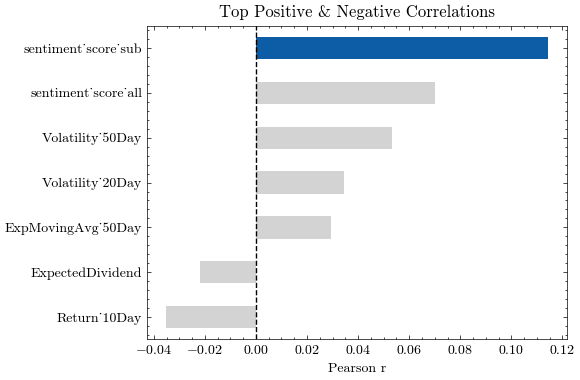

In [34]:

top_neg = corr_with_target.head(2)
top_pos = corr_with_target.tail(5)
subset = pd.concat([top_neg, top_pos]).sort_values()

# build colors (highlight sentiment_score)
colors = ['C0' if feat=='sentiment_score_sub' else 'lightgray'
          for feat in subset.index]

# plot
fig, ax = plt.subplots(figsize=(6, 4))
subset.plot(kind='barh', color=colors, ax=ax)

# dotted vertical line at r=0
ax.axvline(0, linestyle='--', color='black', linewidth=1)

ax.set_title('Top Positive & Negative Correlations')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.savefig('feature', dpi=300)

plt.show()

### Prediction

In [149]:
X = df_numeric.drop(columns=['Target'])
y = df_numeric['Target']
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

R2 score: -0.002488052184299372


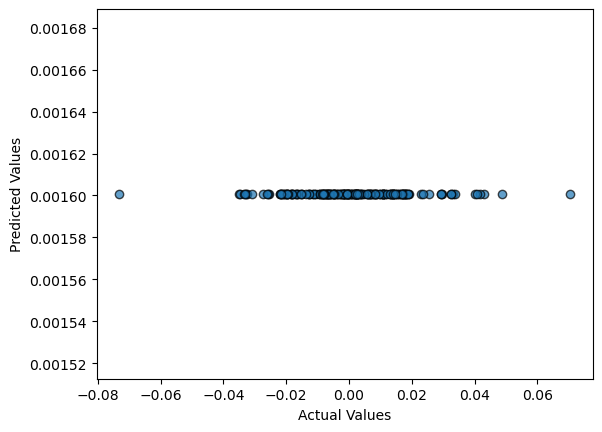

In [ ]:
model = Lasso(alpha=0.1,       
              max_iter=10_000,
              tol=1e-4,
              random_state=0)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print(f"R2 score: {r2}")

plt.scatter(y_test, y_pred, edgecolor='k', alpha=0.7)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')

plt.show()

In [144]:
print(model.coef_)

[-4.77201876e-08  0.00000000e+00  2.96056252e-06 -2.97873103e-06
 -0.00000000e+00  1.32396126e-10  0.00000000e+00  0.00000000e+00
  0.00000000e+00]


In [145]:
features = ['ExpectedDividend']
X = df_numeric.drop(columns=['Target'])
X = X[features]
y = df_numeric['Target']
X.fillna(0, inplace=True)
y.fillna(0, inplace=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [148]:
ridge = Ridge(alpha=1.0,        # regularization strength
              max_iter=10_000,
              tol=1e-4,
              random_state=0)

ridge.fit(X_train_scaled, y_train)

print("Coefficients:", ridge.coef_)
print("Train RMSE:", mean_squared_error(y_train, ridge.predict(X_train_scaled), squared=False))
print("Test  RMSE:", mean_squared_error(y_test,  ridge.predict(X_test_scaled),  squared=False))

Coefficients: [0.00085982]
Train RMSE: 0.019175500261514017
Test  RMSE: 0.01773831463150145


d:\Program Files\anaconda3\envs\dan\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
d:\Program Files\anaconda3\envs\dan\lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
